## Crypto Arbitrage

In [9]:
#dependency imports
import pandas as pd
from pathlib import Path
%matplotlib inline

In [10]:
# Read in the CSV file called "bitstamp.csv" and convert to DataFrame
bitstamp = pd.read_csv(
    Path('Resources/bitstamp.csv'),
    index_col = 'Timestamp',
    parse_dates = True,
    infer_datetime_format = True)

In [11]:
# View DataFrame
display(bitstamp.head())
display(bitstamp.tail())


,Open,High,Low,Close,BTC Volume,USD Volume,Weighted Price
Timestamp,,,,,,,
2018-01-01 00:00:00,13681.04,13681.04,13637.93,$13646.48,3.334553,45482.128785,13639.647479
2018-01-01 00:01:00,13646.48,13658.75,13610.18,$13658.75,2.663188,36361.390888,13653.332816
2018-01-01 00:02:00,13616.93,13616.93,13610.06,$13610.22,0.084653,1152.144036,13610.136247
2018-01-01 00:03:00,13610.27,13639.09,13610.27,$13639.09,7.182986,97856.416478,13623.361128
2018-01-01 00:04:00,13635.35,13636.35,13620.00,$13620.0,1.069665,14582.660932,13632.923329


,Open,High,Low,Close,BTC Volume,USD Volume,Weighted Price
Timestamp,,,,,,,
2018-03-31 23:55:00,6935.01,6939.07,6922.56,$6922.56,1.044354,7240.034602,6932.550078
2018-03-31 23:56:00,6922.02,6922.02,6918.00,$6920.32,3.069539,21245.076275,6921.260233
2018-03-31 23:57:00,6920.33,6936.42,6920.33,$6934.72,28.239049,195789.408220,6933.286106
2018-03-31 23:58:00,6927.65,6929.42,6927.65,$6927.65,0.839507,5817.007705,6929.080007
2018-03-31 23:59:00,6929.98,6929.98,6928.00,$6928.01,0.209363,1450.735763,6929.289993


In [12]:
# Read in the CSV file called "coinbase.csv" and convert to DataFrame
coinbase = pd.read_csv(
    Path('Resources/coinbase.csv'),
    index_col = 'Timestamp',
    parse_dates = True,
    infer_datetime_format = True)

In [13]:
# View DataFrame
display(coinbase.head())
display(coinbase.tail())


,Open,High,Low,Close,BTC Volume,USD Volume,Weighted Price
Timestamp,,,,,,,
2018-01-01 00:00:00,13620.00,13620.00,13608.49,$13608.49,20.812754,283451.08537,13619.105106
2018-01-01 00:01:00,13607.14,13607.14,13601.66,$13601.66,13.474359,183283.97801,13602.426919
2018-01-01 00:02:00,13601.44,13601.44,13580.00,$13580.0,11.536360,156789.19686,13590.872506
2018-01-01 00:03:00,13587.31,13587.31,13542.70,$13550.34,16.328039,221413.64182,13560.332806
2018-01-01 00:04:00,13550.34,13585.95,13550.34,$13583.44,9.955364,135141.26944,13574.719401


,Open,High,Low,Close,BTC Volume,USD Volume,Weighted Price
Timestamp,,,,,,,
2018-03-31 23:55:00,6945.20,6948.06,6930.00,$6930.0,5.802288,40243.918480,6935.869979
2018-03-31 23:56:00,6930.00,6930.01,6930.00,$6930.01,0.625053,4331.620701,6930.005567
2018-03-31 23:57:00,6930.01,6933.91,6930.01,$6933.91,0.776431,5382.532162,6932.405747
2018-03-31 23:58:00,6933.91,6938.00,6933.90,$6937.31,0.133413,925.356547,6936.048538
2018-03-31 23:59:00,6937.30,6937.30,6931.09,$6934.0,1.012720,7022.275088,6934.070316


In [19]:
# Remove na values
bitstamp = bitstamp.dropna()

# Remove '$' 
bitstamp['Close'] = bitstamp['Close'].str.replace('$', '')

type(bitstamp['Close'])

/var/folders/xg/946270fx4lq1f8wbv72rc_lc0000gn/T/ipykernel_25001/2492178258.py:5: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will*not* be treated as literal strings when regex=True.
  bitstamp['Close'] = bitstamp['Close'].str.replace('$', '')


pandas.core.series.Series

In [ ]:
# Convert the Close data type to a float
bitstamp['Close'] = bitstamp['Close'].astype('float')


In [ ]:
# Review the data for duplicate values, and drop them if necessary
bitstamp.duplicated()
bitstamp = bitstamp.drop_duplicates()

#Verify all duplicates have been dropped
bitstamp.duplicated().sum()

0

In [ ]:
# Repeat Steps 1–4 for the coinbase DataFrame
# Drop NaN values in coinbase df
coinbase = coinbase.dropna()

# Remove '$' in coinbase['Close'] 
coinbase['Close'] = coinbase['Close'].str.replace('$', '')

# Convert coinbase['Close'] to float dtype
coinbase['Close'] = coinbase['Close'].astype('float')

# Find duplicate values, drop if necessary
coinbase.duplicated()
coinbase = coinbase.drop_duplicates()

/opt/anaconda3/envs/dev/lib/python3.7/site-packages/ipykernel_launcher.py:6: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  


In [ ]:
# Verify duplicates have been dropped
coinbase.duplicated().sum()

0

In [ ]:
# Use loc or iloc to select `Timestamp (the index)` and `Close` from bitstamp DataFrame
bitstamp_sliced = bitstamp.iloc[:, 3]
# Review the first five rows of the DataFrame
bitstamp_sliced.head()


Timestamp
2018-01-01 00:00:00    13646.48
2018-01-01 00:01:00    13658.75
2018-01-01 00:02:00    13610.22
2018-01-01 00:03:00    13639.09
2018-01-01 00:04:00    13620.00
Name: Close, dtype: float64

In [ ]:
# Use loc or iloc to select `Timestamp (the index)` and `Close` from coinbase DataFrame
coinbase_sliced = coinbase.iloc[:, 3]

# Review the first five rows of the DataFrame
coinbase_sliced.head()


Timestamp
2018-01-01 00:00:00    13608.49
2018-01-01 00:01:00    13601.66
2018-01-01 00:02:00    13580.00
2018-01-01 00:03:00    13550.34
2018-01-01 00:04:00    13583.44
Name: Close, dtype: float64

In [ ]:
# Generate the summary statistics for the bitstamp DataFrame
bitstamp_sliced.describe()


count    129067.000000
mean      10459.842453
std        2315.976088
min        5944.000000
25%        8613.370000
50%       10145.950000
75%       11444.810000
max       17234.980000
Name: Close, dtype: float64

In [ ]:
# Generate the summary statistics for the coinbase DataFrame
coinbase_sliced.describe()


count    129322.000000
mean      10449.140958
std        2317.197419
min        5882.310000
25%        8609.230000
50%       10137.440000
75%       11397.237500
max       17177.990000
Name: Close, dtype: float64

<AxesSubplot:title={'center':'Closing Prices of Bitcoin on Bitstamp Exchange'}, xlabel='Date', ylabel='Closing Price'>

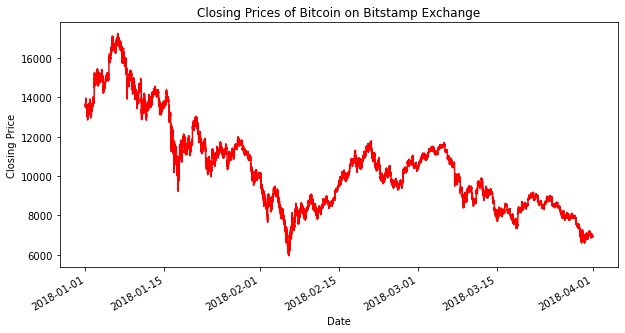

In [ ]:
# Create a line plot for the bitstamp DataFrame for the full length of time in the dataset 
# Be sure that the figure size, title, and color are tailored to each visualization
bitstamp_sliced.plot(
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp Exchange',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)


<AxesSubplot:title={'center':'Closing Prices of Bitcoin on Coinbase Exchange'}, xlabel='Date', ylabel='Closing Price'>

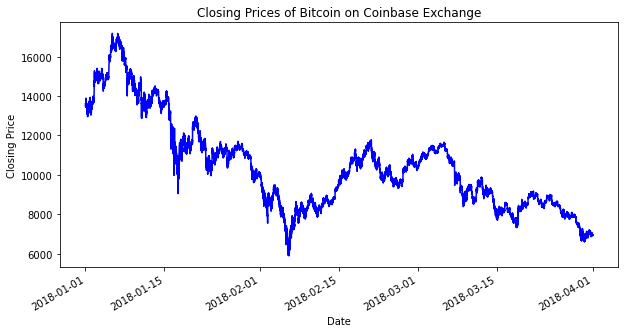

In [ ]:
# Create a line plot for the coinbase DataFrame for the full length of time in the dataset 
# Be sure that the figure size, title, and color are tailored to each visualization
coinbase_sliced.plot(
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Coinbase Exchange',
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)


<AxesSubplot:title={'center':'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange'}, xlabel='Date', ylabel='Closing Price'>

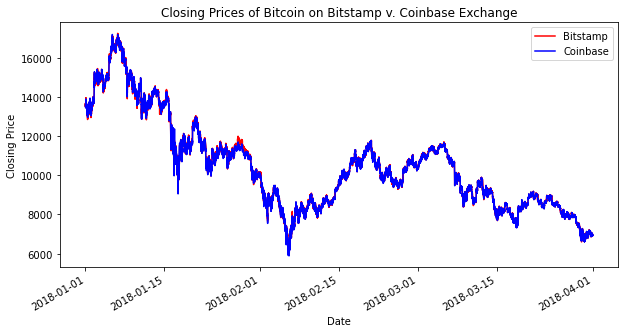

In [ ]:
# Overlay the visualizations for the bitstamp and coinbase DataFrames in one plot
# The plot should visualize the prices over the full lenth of the dataset
# Be sure to include the parameters: legend, figure size, title, and color and label
bitstamp.iloc[:,3].plot(
    legend = True,
    label = 'Bitstamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase.iloc[:,3].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)





<AxesSubplot:title={'center':'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange Between 2016-05-01 and 2016-05-31'}, xlabel='Date', ylabel='Closing Price'>

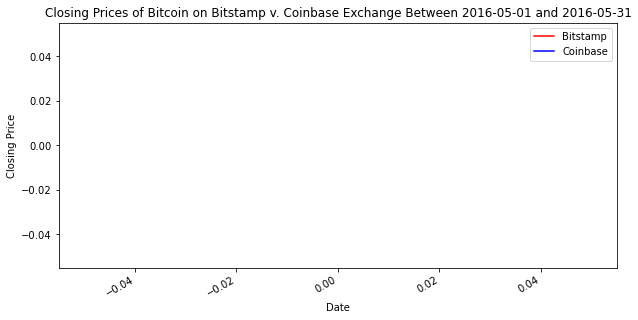

In [ ]:
# Using the loc and plot functions, create an overlay plot that visualizes 
# the price action of both DataFrames for a one month period early in the dataset
# Be sure to include the parameters: legend, figure size, title, and color and label
bitstamp_sliced.loc['2016-05-01':'2016-05-31'].plot(
    legend = True,
    label = 'Bitstamp',
    x = 'Timestamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange Between 2016-05-01 and 2016-05-31',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase_sliced.loc['2016-05-01':'2016-05-31'].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)

<AxesSubplot:title={'center':'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange Between 2018-12-01 and 2018-12-31'}, xlabel='Date', ylabel='Closing Price'>

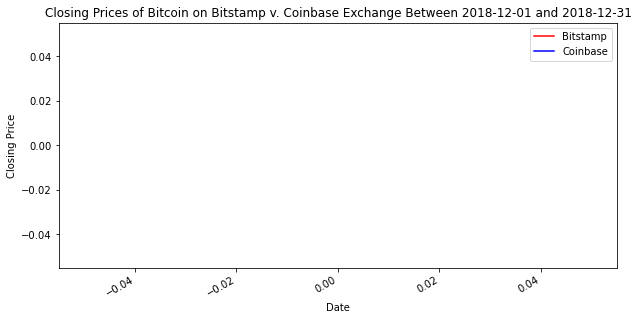

In [ ]:
# Using the loc and plot functions, create an overlay plot that visualizes 
# the price action of both DataFrames for a one month period later in the dataset
# Be sure to include the parameters: legend, figure size, title, and color and label 
bitstamp_sliced.loc['2018-12-01':'2018-12-31'].plot(
    legend = True,
    label = 'Bitstamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange Between 2018-12-01 and 2018-12-31',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase_sliced.loc['2018-12-01':'2018-12-31'].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)


In [ ]:
# Create an overlay plot that visualizes the two dataframes over a period of one day early in the dataset 
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label` 
bitstamp_sliced.loc['2016-05-09'].plot(
    legend = True,
    label = 'Bitstamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange on 2016-05-09',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase_sliced.loc['2016-05-09'].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)


KeyError: '2016-05-09'

In [ ]:
# Using the early date that you have selected, calculate the arbitrage spread 
# by subtracting the bitstamp lower closing prices from the coinbase higher closing prices
arbitrage_spread_early = coinbase_sliced.loc['2016-05-09'] - bitstamp_sliced.loc['2016-05-09']

# Generate summary statistics for the early DataFrame
arbitrage_spread_early.describe()


In [ ]:
# Visualize the arbitrage spread from early in the dataset in a box plot
# Be sure to include at least a title with your plot
arbitrage_spread_early.plot.box(
    title = 'Arbitrage Spread: Bitstamp v. Coinbase Exchange on 2016-05-09'
)


In [ ]:
# Create an overlay plot that visualizes the two dataframes over a period of one day from the middle of the dataset. 
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label` 
bitstamp_sliced.loc['2017-09-09'].plot(
    legend = True,
    label = 'Bitstamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange on 2017-09-09',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase_sliced.loc['2017-09-09'].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)


In [ ]:
# Using the date form the middle that you have selected, calculate the arbitrage spread 
# by subtracting the bitstamp lower closing prices from the coinbase higher closing prices
arbitrage_spread_middle = coinbase_sliced.loc['2017-09-09'] - bitstamp_sliced.loc['2017-09-09']

# Generate summary statistics for the middle DataFrame
arbitrage_spread_middle.describe()


In [ ]:
# Visualize the arbitrage spread from the middle of the dataset in a box plot
# Be sure to include at least a title with your plot
arbitrage_spread_middle.plot.box(
    title = 'Arbitrage Spread: Bitstamp v. Coinbase Exchange on 2017-09-09'
)



In [ ]:
# Create an overlay plot that visualizes the two dataframes over a period of one day from late in the dataset
# Be sure that the plots include the parameters `legend`, `figsize`, `title`, `color` and `label` 
bitstamp_sliced.loc['2018-12-26'].plot(
    legend = True,
    label = 'Bitstamp',
    figsize = (10, 5),
    title = 'Closing Prices of Bitcoin on Bitstamp v. Coinbase Exchange on 2018-12-26',
    color = 'red',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)
coinbase_sliced.loc['2018-12-26'].plot(
    legend = True,
    label = 'Coinbase',
    figsize = (10, 5),
    color = 'blue',
    ylabel = 'Closing Price',
    xlabel = 'Date'
)



In [ ]:
# Using th date from late in the dataset that you have selected, calculate the arbitrage spread 
# by subtracting the bitstamp lower closing prices from the coinbase higher closing prices
arbitrage_spread_late = coinbase_sliced.loc['2018-12-26'] - bitstamp_sliced.loc['2018-12-26']

# Generate summary statistics for the late DataFrame
arbitrage_spread_late.describe()


In [ ]:
# Visualize the arbitrage spread from late in the dataset in a box plot
# Be sure to include at least a title with your plot
arbitrage_spread_late.plot.box(
    title = 'Arbitrage Spread: Bitstamp v. Coinbase Exchange on 2018-12-26'
)


In [ ]:
# For the date early in the dataset, measure the arbitrage spread between the two exchanges
# by subtracting the lower-priced exchange from the higher-priced one
arbitrage_spread_early = coinbase_sliced.loc['2016-05-09'] - bitstamp_sliced.loc['2016-05-09']

# Use a conditional statement to generate the summary statistics for each arbitrage_spread DataFrame
arbitrage_spread_early[arbitrage_spread_early>0].describe()



In [ ]:
# For the from the middle of the dataset, measure the arbitrage spread between the two exchanges
# by subtracting the lower-priced exchange from the higher-priced one
arbitrage_spread_middle = coinbase_sliced.loc['2017-09-09'] - bitstamp_sliced.loc['2017-09-09']

# Use a conditional statement to generate the summary statistics for each arbitrage_spread DataFrame
arbitrage_spread_middle[arbitrage_spread_middle>0].describe()


In [ ]:
# For the date late in the dataset, measure the arbitrage spread between the two exchanges
# by subtracting the lower-priced exchange from the higher-priced one
arbitrage_spread_late = coinbase_sliced.loc['2018-12-26'] - bitstamp_sliced.loc['2018-12-26']

# Use a conditional statement to generate the summary statistics for each arbitrage_spread DataFrame

arbitrage_spread_late[arbitrage_spread_late>0].describe()


In [ ]:
# For the date early in the dataset, calculate the spread returns by dividing 
# the instances when the arbitrage spread is positive (> 0) by the price of Bitcoin 
# from the exchange you are buying on (the lower-priced exchange)
spread_return_early = arbitrage_spread_early[arbitrage_spread_early>0] / bitstamp_sliced.loc['2016-05-09']

# Review the spread return DataFrame
spread_return_early = spread_return_early.dropna()
spread_return_early 


In [ ]:
# For the date in the middle of the dataset, calculate the spread returns by dividing 
# the instances when the arbitrage spread is positive (> 0)  by the price of Bitcoin 
# from the exchange you are buying on (the lower-priced exchange)
spread_return_middle = arbitrage_spread_middle[arbitrage_spread_middle>0] / bitstamp_sliced.loc['2017-09-09']

# Review the spread return DataFrame
spread_return_middle = spread_return_middle.dropna()
spread_return_middle


In [ ]:
# For the date late in the dataset, calculate the spread returns by dividing 
# the instances when the arbitrage spread is positive (> 0)  by the price of Bitcoin 
# from the exchange you are buying on (the lower-priced exchange)
spread_return_late = arbitrage_spread_late[arbitrage_spread_late>0] / bitstamp_sliced.loc['2018-12-26']

# Review the spread return DataFrame
spread_return_late = spread_return_late.dropna()
spread_return_late

In [ ]:
# For the date early in the dataset, determine the number of times your trades with positive returns 
# exceed the 1% minimum threshold (.01) that you need to cover your costs
profitable_trades_early = spread_return_early[spread_return_early > .01]

# Review the first five profitable trades
profitable_trades_early.head()


In [ ]:
# For the date in the middle of the dataset, determine the number of times your trades with positive returns 
# exceed the 1% minimum threshold (.01) that you need to cover your costs
profitable_trades_middle = spread_return_middle[spread_return_middle > .01]

# Review the first five profitable trades
profitable_trades_middle.head()


In [ ]:
# For the date late in the dataset, determine the number of times your trades with positive returns 
# exceed the 1% minimum threshold (.01) that you need to cover your costs
profitable_trades_late = spread_return_late[spread_return_late > .01]

# Review the first five profitable trades
profitable_trades_late.head()


In [ ]:
# For the date early in the dataset, generate the summary statistics for the profitable trades
# or you trades where the spread returns are are greater than 1%
profitable_trades_early.describe()


In [ ]:
# For the date in the middle of the dataset, generate the summary statistics for the profitable trades
# or you trades where the spread returns are are greater than 1%
profitable_trades_middle.describe()


In [ ]:
# For the date late in the dataset, generate the summary statistics for the profitable trades
# or you trades where the spread returns are are greater than 1%
profitable_trades_late.describe()


In [ ]:
# For the date early in the dataset, calculate the potential profit per trade in dollars 
# Multiply the profitable trades by the cost of the Bitcoin that was purchased
profit_early = profitable_trades_early * bitstamp_sliced.loc['2016-05-09']

# Drop any missing values from the profit DataFrame
profit_per_trade_early = profit_early.dropna()

# View the early profit DataFrame
profit_per_trade_early


In [ ]:
# For the date in the middle of the dataset, calculate the potential profit per trade in dollars 
# Multiply the profitable trades by the cost of the Bitcoin that was purchased
profit_middle = profitable_trades_middle * bitstamp_sliced.loc['2017-09-09']

# Drop any missing values from the profit DataFrame
profit_per_trade_middle = profit_middle.dropna()

# View the early profit DataFrame
profit_per_trade_middle


In [ ]:
# For the date late in the dataset, calculate the potential profit per trade in dollars 
# Multiply the profitable trades by the cost of the Bitcoin that was purchased
profit_late = profitable_trades_late * bitstamp_sliced.loc['2018-12-26']

# Drop any missing values from the profit DataFrame
profit_per_trade_late = profit_late.dropna()

# View the early profit DataFrame
profit_per_trade_late


In [ ]:
# Generate the summary statistics for the early profit per trade DataFrame
profit_per_trade_early.describe()


In [ ]:
# Plot the results for the early profit per trade DataFrame
# Be sure to include at least a title with your plot
profit_per_trade_early.plot(
    figsize = (10, 7),
    title = 'Bitcoin Profits: 2016-05-09')


In [ ]:
# Generate the summary statistics for the middle profit per trade DataFrame
profit_per_trade_middle.describe()


In [ ]:
# Plot the results for the middle profit per trade DataFrame
# Be sure to include at least a title with your plot
profit_per_trade_middle.plot(
    figsize = (10, 7),
    title = 'Bitcoin Profits: 2017-09-09')


In [ ]:
# Generate the summary statistics for the late profit per trade DataFrame
profit_per_trade_late.describe()


In [ ]:
# Plot the results for the late profit per trade DataFrame
# Be sure to include at least a title with your plot
profit_per_trade_late.plot(
    figsize = (10, 7),
    title = 'Bitcoin Profits: 2018-12-26')


In [ ]:
# Calculate the sum of the potential profits for the early profit per trade DataFrame
profit_sum_early = profit_per_trade_early.sum()
profit_sum_early

In [ ]:
# Calculate the sum of the potential profits for the middle profit per trade DataFrame
profit_sum_middle = profit_per_trade_middle.sum()
profit_sum_middle

In [ ]:
# Calculate the sum of the potential profits for the late profit per trade DataFrame
profit_sum_late = profit_per_trade_late.sum()
profit_sum_late

In [ ]:
# Use the cumsum function to calculate the cumulative profits over time for the early profit per trade DataFrame
cumulative_profit_early = profit_per_trade_early.cumsum()


In [ ]:
# Plot the cumulative sum of profits for the early profit per trade DataFrame
# Be sure to include at least a title with your plot
cumulative_profit_early.plot(
    figsize = (10,7),
    title = 'Cumulative Bitcoin Profits: 2016-05-09')

In [ ]:
# Use the cumsum function to calculate the cumulative profits over time for the middle profit per trade DataFrame
cumulative_profit_middle = profit_per_trade_middle.cumsum()


In [ ]:
# Plot the cumulative sum of profits for the early profit per trade DataFrame
# Be sure to include at least a title with your plot
cumulative_profit_middle.plot(
    figsize = (10,7),
    title = 'Cumulative Bitcoin Profits: 2017-09-09')


In [ ]:
# Use the cumsum function to calculate the cumulative profits over time for the late profit per trade DataFrame
cumulative_profit_late = profit_per_trade_late.cumsum()


In [ ]:
# Plot the cumulative sum of profits for the early profit per trade DataFrame
# Be sure to include at least a title with your plot
cumulative_profit_late.plot(
    figsize = (10,7),
    title = 'Cumulative Bitcoin Profits: 2018-12-26')
